# Song Familiarity Analysis-Ready Dataset With EEG

This notebook treats `ds005876/` as the canonical dataset checkout, derives trial-level behavioral and event features, extracts simple EEG summary measures directly from the EEGLAB `.set` / `.fdt` files, and writes merged tables to `analysis/` plus figures to `visuals/analysis_ready/`.


## Pipeline Overview

1. Walk through the BIDS dataset subject-by-subject and load behavior, event logs, participant metadata, and EEG files from `ds005876/`.
2. Derive note-density features from `events.tsv`, epoch the first 2 seconds after each stimulus onset, and summarize each epoch with global field power plus broad-band spectral power.
3. Save reusable trial-, participant-, song-, and EEG-level tables that the later modeling notebooks can consume without repeating the expensive extraction work.

This notebook is the handoff between raw-ish BIDS data and the smaller analysis tables used everywhere else in the branch.


## Detailed Transformation Map

This notebook turns the raw BIDS dataset into modeling-ready tables by applying the same sequence for every participant:

1. Load the study-level metadata in `participants.tsv` and derive session-level calendar features that can later be used as covariates.
2. Read each subject's behavioral TSV as the primary trial table, then assign a zero-based `trial_index` so behavior, events, and EEG can be aligned without relying on row order implicitly.
3. Parse each subject's `events.tsv` to identify the stimulus onset that starts a trial, count all `noteOnset` events until the next stimulus onset, and convert that event stream into `note_count`, `trial_window_sec`, and `note_rate`.
4. Read the EEGLAB `.set` file for the same subject, epoch the first 2 seconds after each trial onset, and summarize each epoch with global field power plus Welch power in the delta, theta, alpha, and beta bands.
5. Merge the behavioral, participant-level, note-density, and EEG features on `participant_id` and `trial_index`, clean data types, derive helper columns such as valid-response flags and log-transformed power, then aggregate participant- and song-level summaries from the merged trial table.

The result is four exported CSV files in `analysis/`:

- `analysis_ready_familiarity_trials.csv`: the fully merged trial-level table used by downstream models.
- `analysis_ready_participant_summary.csv`: one row per participant with response, accuracy, and average EEG summaries.
- `analysis_ready_song_summary.csv`: one row per song with familiarity rates, timing summaries, and average note / EEG features.
- `analysis_ready_eeg_trial_features.csv`: the EEG-only per-trial feature table before it is merged back into the behavioral rows.


## 1. Build Merged Analysis Tables

The extraction cell below is the core transformation pipeline. It starts with the raw BIDS checkout in `ds005876/`, constructs subject-level intermediate tables, and ends by writing reusable CSVs to `analysis/`.

The logic is easier to follow if you read it in five blocks:

1. Configuration: define directories, frequency bands, epoch boundaries, and plotting style.
2. Helper transforms: convert raw event logs into note-density features and raw EEG into compact per-trial band-power summaries.
3. Subject loop: load each participant's behavior file, attach note features, and collect EEG features when the necessary files exist.
4. Trial-level feature engineering: coerce columns into numeric form, add response flags, merge participant metadata, normalize some variables, and create log power features.
5. Aggregation and export: compute participant-level and song-level summaries, merge those summaries back into the trial table, and write the final artifacts.

The inline comments in the code intentionally explain both what each block does and why the transformation is structured that way.


In [1]:
from pathlib import Path
import warnings
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

# Keep the notebook visuals consistent with the rest of the project outputs.
PALETTE = ["#16324F", "#2A9D8F", "#E9C46A", "#E76F51", "#6D597A", "#264653"]
sns.set_theme(style="whitegrid", context="notebook", palette=PALETTE)

# Broad EEG bands used later as compact neural summary features.
BANDS = {
    "delta_power": (1, 4),
    "theta_power": (4, 8),
    "alpha_power": (8, 13),
    "beta_power": (13, 30),
}
EPOCH_TMIN = 0.0
EPOCH_TMAX = 2.0


def locate_project_root() -> Path:
    # The notebook may be run from the repo root or from notebooks/, so probe both.
    for candidate in [Path.cwd(), Path.cwd().parent]:
        if (candidate / "ds005876").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing ds005876.")


ROOT = locate_project_root()
DATA_DIR = ROOT / "ds005876"
ANALYSIS_DIR = ROOT / "analysis"
PLOT_DIR = ROOT / "visuals" / "analysis_ready"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def compute_note_features(events_path: Path) -> pd.DataFrame:
    # Event logs contain both trial-start markers and note-level annotations.
    # We collapse that richer stream into one row per trial so behavior rows can
    # later inherit a simple "how dense was the melody?" feature set.
    events_df = pd.read_csv(events_path, sep="\t")

    # A value of "1" with a real stimulus file marks the onset of a presented song.
    trial_starts = events_df[
        (events_df["value"].astype(str) == "1")
        & (events_df["stim_file"].astype(str) != "n/a")
    ].reset_index(drop=True)

    rows = []
    for idx in range(len(trial_starts)):
        start_onset = trial_starts.iloc[idx]["onset"]

        # The note-count window runs until the next song starts. For the last trial,
        # fall back to the final event plus one extra second so the terminal window
        # still has a positive duration.
        end_onset = (
            trial_starts.iloc[idx + 1]["onset"]
            if idx + 1 < len(trial_starts)
            else events_df["onset"].iloc[-1] + 1
        )

        note_mask = (
            (events_df["value"].astype(str) == "noteOnset")
            & (events_df["onset"] >= start_onset)
            & (events_df["onset"] < end_onset)
        )
        duration = end_onset - start_onset
        note_count = int(note_mask.sum())

        rows.append(
            {
                "trial_index": idx,
                "note_count": note_count,
                "trial_window_sec": duration,
                "note_rate": note_count / duration if duration > 0 else np.nan,
            }
        )

    return pd.DataFrame(rows)


def extract_subject_eeg_features(participant_id: str) -> pd.DataFrame | None:
    # The behavioral TSV is the master trial table, so EEG features are extracted
    # separately and keyed by participant + trial_index for a later merge.
    set_path = DATA_DIR / participant_id / "eeg" / f"{participant_id}_task-songfamiliarity_eeg.set"
    events_path = DATA_DIR / participant_id / "eeg" / f"{participant_id}_task-songfamiliarity_events.tsv"
    if not set_path.exists() or not events_path.exists():
        return None

    events_df = pd.read_csv(events_path, sep="\t")
    trial_starts = events_df[
        (events_df["value"].astype(str) == "1")
        & (events_df["stim_file"].astype(str) != "n/a")
    ].reset_index(drop=True)
    if trial_starts.empty:
        return None

    raw = mne.io.read_raw_eeglab(set_path, preload=True, verbose=False)
    eeg_picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
    sfreq = raw.info["sfreq"]

    # Convert onset seconds into MNE's integer sample-based event format.
    events = np.column_stack(
        [
            (trial_starts["onset"].to_numpy(dtype=float) * sfreq).astype(int),
            np.zeros(len(trial_starts), dtype=int),
            np.ones(len(trial_starts), dtype=int),
        ]
    )

    # Each trial is summarized over the first two seconds after song onset.
    epochs = mne.Epochs(
        raw,
        events,
        event_id={"trial": 1},
        tmin=EPOCH_TMIN,
        tmax=EPOCH_TMAX,
        baseline=None,
        picks=eeg_picks,
        preload=True,
        on_missing="ignore",
        verbose=False,
    )
    if len(epochs) == 0:
        return None

    epoch_data = epochs.get_data(copy=True)
    spectrum = epochs.compute_psd(method="welch", fmin=1, fmax=40, verbose=False)
    psds, freqs = spectrum.get_data(return_freqs=True)

    rows = []
    for trial_index in range(psds.shape[0]):
        average_psd = psds[trial_index].mean(axis=0)

        # Global field power is a compact measure of how much the scalp-wide signal
        # varies over time within the epoch. Multiplying by 1e6 expresses it in uV.
        row = {
            "participant_id": participant_id,
            "trial_index": trial_index,
            "global_field_power": float(epoch_data[trial_index].std(axis=0).mean() * 1e6),
        }

        # Collapse the power spectrum into broad frequency-band averages so the
        # downstream models can use a small, interpretable EEG feature set.
        for band_name, (low_hz, high_hz) in BANDS.items():
            band_mask = (freqs >= low_hz) & (freqs < high_hz)
            row[band_name] = float(average_psd[band_mask].mean())
        rows.append(row)

    return pd.DataFrame(rows)


# Study-level metadata is loaded once and expanded with calendar-derived fields
# before the subject loop begins. Those fields are later merged into every trial.
participants = pd.read_csv(DATA_DIR / "participants.tsv", sep="\t")
participants["datetime"] = pd.to_datetime(
    participants["datetime"], format="%d-%b-%Y %H:%M:%S"
)
participants["session_date"] = participants["datetime"].dt.date.astype(str)
participants["session_month"] = participants["datetime"].dt.to_period("M").astype(str)
participants["session_weekday"] = participants["datetime"].dt.day_name()

behavior_frames = []
eeg_feature_frames = []

# Process each subject independently so missing files only affect that subject
# instead of breaking the full dataset build.
for participant_id in sorted(path.name for path in DATA_DIR.glob("sub-*") if path.is_dir()):
    behavior_path = DATA_DIR / participant_id / "beh" / f"{participant_id}_task-songfamiliarity_beh.tsv"
    events_path = DATA_DIR / participant_id / "eeg" / f"{participant_id}_task-songfamiliarity_events.tsv"
    if not behavior_path.exists():
        continue

    # The behavioral table is the canonical trial roster.
    behavior_df = pd.read_csv(behavior_path, sep="\t")
    behavior_df["participant_id"] = participant_id
    behavior_df["trial_index"] = np.arange(len(behavior_df))

    # Event-derived note features are attached directly to the behavioral rows.
    if events_path.exists():
        behavior_df = behavior_df.merge(
            compute_note_features(events_path), on="trial_index", how="left"
        )
    behavior_frames.append(behavior_df)

    # EEG is extracted into its own trial-indexed table and merged later so trials
    # without EEG still remain in the master behavioral dataset.
    eeg_df = extract_subject_eeg_features(participant_id)
    if eeg_df is not None:
        eeg_feature_frames.append(eeg_df)


# Stack all participant-level tables into project-wide trial-level datasets.
trial_df = pd.concat(behavior_frames, ignore_index=True)
eeg_features = pd.concat(eeg_feature_frames, ignore_index=True)

# Behavioral timing columns arrive as strings in the raw TSVs, so coerce them to
# numeric form once here and preserve NaNs for genuinely missing values.
for col in ["rt", "promptRT", "rtMC"]:
    trial_df[f"{col}_numeric"] = pd.to_numeric(trial_df[col], errors="coerce")

trial_df["responded"] = pd.to_numeric(trial_df["responded"], errors="coerce").fillna(0).astype(int)
trial_df["outcomeMC"] = pd.to_numeric(trial_df["outcomeMC"], errors="coerce")
trial_df["respMC"] = pd.to_numeric(trial_df["respMC"], errors="coerce")

# Merge in subject-level metadata first, then trial-level EEG summaries.
trial_df = trial_df.merge(participants, on="participant_id", how="left")
trial_df = trial_df.merge(eeg_features, on=["participant_id", "trial_index"], how="left")

# These helper columns make downstream modeling and filtering explicit rather than
# forcing later notebooks to repeat the same cleaning logic.
trial_df["reply_present"] = trial_df["reply"].fillna("").astype(str).str.strip().ne("")
trial_df["valid_familiarity_rt"] = trial_df["rt_numeric"].notna()
trial_df["responded_label"] = trial_df["responded"].map({0: "Not familiar", 1: "Familiar"})
trial_df["trial_progress"] = trial_df.groupby("participant_id")["trialNum"].transform(
    lambda s: s / s.max()
)
trial_df["age_zscore"] = (
    trial_df["age"] - trial_df["age"].mean()
) / trial_df["age"].std(ddof=0)
trial_df["song_name_clean"] = trial_df["songFileName"].str.replace(".wav", "", regex=False)

# Log power is often easier to model and visualize than raw PSD magnitudes.
for band_name in BANDS:
    trial_df[f"log_{band_name}"] = np.log10(trial_df[band_name])


# Aggregate participant-level summaries from the fully merged trial table so every
# participant metric reflects the same cleaning and merge decisions as the trials.
participant_summary = (
    trial_df.groupby("participant_id")
    .agg(
        participant_trial_count=("trialNum", "size"),
        participant_response_rate=("responded", "mean"),
        participant_mc_accuracy=("outcomeMC", "mean"),
        participant_median_rt=("rt_numeric", "median"),
        mean_global_field_power=("global_field_power", "mean"),
        mean_alpha_power=("alpha_power", "mean"),
        mean_beta_power=("beta_power", "mean"),
        age=("age", "first"),
        sex=("sex", "first"),
        handedness=("handedness", "first"),
        cch=("cch", "first"),
        session_date=("session_date", "first"),
    )
    .reset_index()
)
participant_summary["log_mean_alpha_power"] = np.log10(participant_summary["mean_alpha_power"])
participant_summary["log_mean_beta_power"] = np.log10(participant_summary["mean_beta_power"])

# Aggregate song-level summaries to capture how recognizable each melody is across
# all listeners and to create reusable song-level covariates.
song_summary = (
    trial_df.groupby("songFileName")
    .agg(
        song_sample_n=("songFileName", "size"),
        song_response_rate=("responded", "mean"),
        song_mean_rt=("rt_numeric", "mean"),
        song_median_rt=("rt_numeric", "median"),
        song_mc_accuracy=("outcomeMC", "mean"),
        mean_note_rate=("note_rate", "mean"),
        song_mean_alpha_power=("alpha_power", "mean"),
        song_mean_beta_power=("beta_power", "mean"),
    )
    .reset_index()
)
song_summary["song_name_clean"] = song_summary["songFileName"].str.replace(".wav", "", regex=False)

# Bring the aggregated participant/song summaries back onto each trial row so the
# modeling notebook can access both granular and grouped features from one table.
trial_df = trial_df.merge(
    participant_summary.drop(columns=["age", "sex", "handedness", "cch", "session_date"]),
    on="participant_id",
    how="left",
)
trial_df = trial_df.merge(
    song_summary,
    on=["songFileName", "song_name_clean"],
    how="left",
)

# Persist each table separately so downstream analyses can choose the right grain
# without having to rerun EEG extraction or event-log parsing.
trial_df.to_csv(ANALYSIS_DIR / "analysis_ready_familiarity_trials.csv", index=False)
participant_summary.to_csv(ANALYSIS_DIR / "analysis_ready_participant_summary.csv", index=False)
song_summary.to_csv(ANALYSIS_DIR / "analysis_ready_song_summary.csv", index=False)
eeg_features.to_csv(ANALYSIS_DIR / "analysis_ready_eeg_trial_features.csv", index=False)

# Show a lightweight audit so the notebook itself documents what was created.
display(
    pd.DataFrame(
        {
            "table": [
                "trial_df",
                "participant_summary",
                "song_summary",
                "eeg_features",
            ],
            "rows": [
                len(trial_df),
                len(participant_summary),
                len(song_summary),
                len(eeg_features),
            ],
            "columns": [
                trial_df.shape[1],
                participant_summary.shape[1],
                song_summary.shape[1],
                eeg_features.shape[1],
            ],
        }
    )
)
display(trial_df.head())
print(f"Project root: {ROOT}")
print(f"Dataset directory: {DATA_DIR}")
print(f"Participants in ds005876: {participant_summary.shape[0]}")
print(f"EEG trial rows extracted: {len(eeg_features)}")
print(f"Trials with valid familiarity RT: {int(trial_df['valid_familiarity_rt'].sum())}")


,table,rows,columns
0,trial_df,2074,63
1,participant_summary,29,15
2,song_summary,121,10
3,eeg_features,2074,7


,trialNum,songNumber,songFileName,songDur,fixTime,responded,rt,postMusicTime,reply,promptRT,...,log_mean_alpha_power,log_mean_beta_power,song_sample_n,song_response_rate,song_mean_rt,song_median_rt,song_mc_accuracy,mean_note_rate,song_mean_alpha_power,song_mean_beta_power
0,1,34,do wah ditty.wav,7.758005,0.457367,0,NaN,0.491517,NaN,11.723581,...,-11.844825,-12.956839,19,0.157895,5.114998,5.891816,0.368421,1.695857,8.795414e-13,1.844593e-13
1,2,11,alouette.wav,5.946984,0.450400,1,2.872449,0.462234,Frere Jaque,8.877756,...,-11.844825,-12.956839,19,0.684211,3.367871,3.124987,0.789474,1.219712,1.024081e-12,1.721742e-13
2,3,45,great escape.wav,15.750023,0.458773,1,10.306871,0.488652,EEG Lab,7.080602,...,-11.844825,-12.956839,17,0.529412,8.197510,8.843084,0.411765,1.696379,7.851493e-13,1.970359e-13
3,4,24,buffalo gals.wav,9.331020,0.472790,1,3.721228,0.481305,Childhood lullaby,7.650939,...,-11.844825,-12.956839,15,0.866667,5.201301,4.490193,0.266667,1.484581,6.264015e-13,1.813076e-13
4,5,85,over the river and through the woods.wav,13.913016,0.452219,0,NaN,0.402142,NaN,30.119903,...,-11.844825,-12.956839,19,0.631579,6.927159,6.079535,0.684211,3.234655,5.860991e-13,1.899572e-13


Project root: C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26
Dataset directory: C:\Users\jnhdv\School Projects\COGS 189\COGS-189-Group-Project-WI26\ds005876
Participants in ds005876: 29
EEG trial rows extracted: 2074
Trials with valid familiarity RT: 1030


## 2. Descriptive QA of the Transformed Tables

Everything below this point uses the already transformed tables as a quality check. These figures are not creating new exported data; they are validating that the merged outputs look plausible and that later models will be working with structured variation rather than obvious extraction artifacts.

The plotting cell first creates filtered analysis subsets:

- `responded_trials`: trials with a usable familiarity reaction time.
- `frequent_songs`: songs with at least 10 observations so song-level summaries are less noisy.
- `eeg_ready_trials`: trials that successfully received the main EEG summary features.
- `responded_eeg_trials`: the overlap of valid familiarity RTs and valid EEG summaries.

The resulting plots check participant heterogeneity, song heterogeneity, note-density relationships, and a few simple EEG-behavior associations. They act as a sanity check on the transformation pipeline rather than as the notebook's main deliverable.


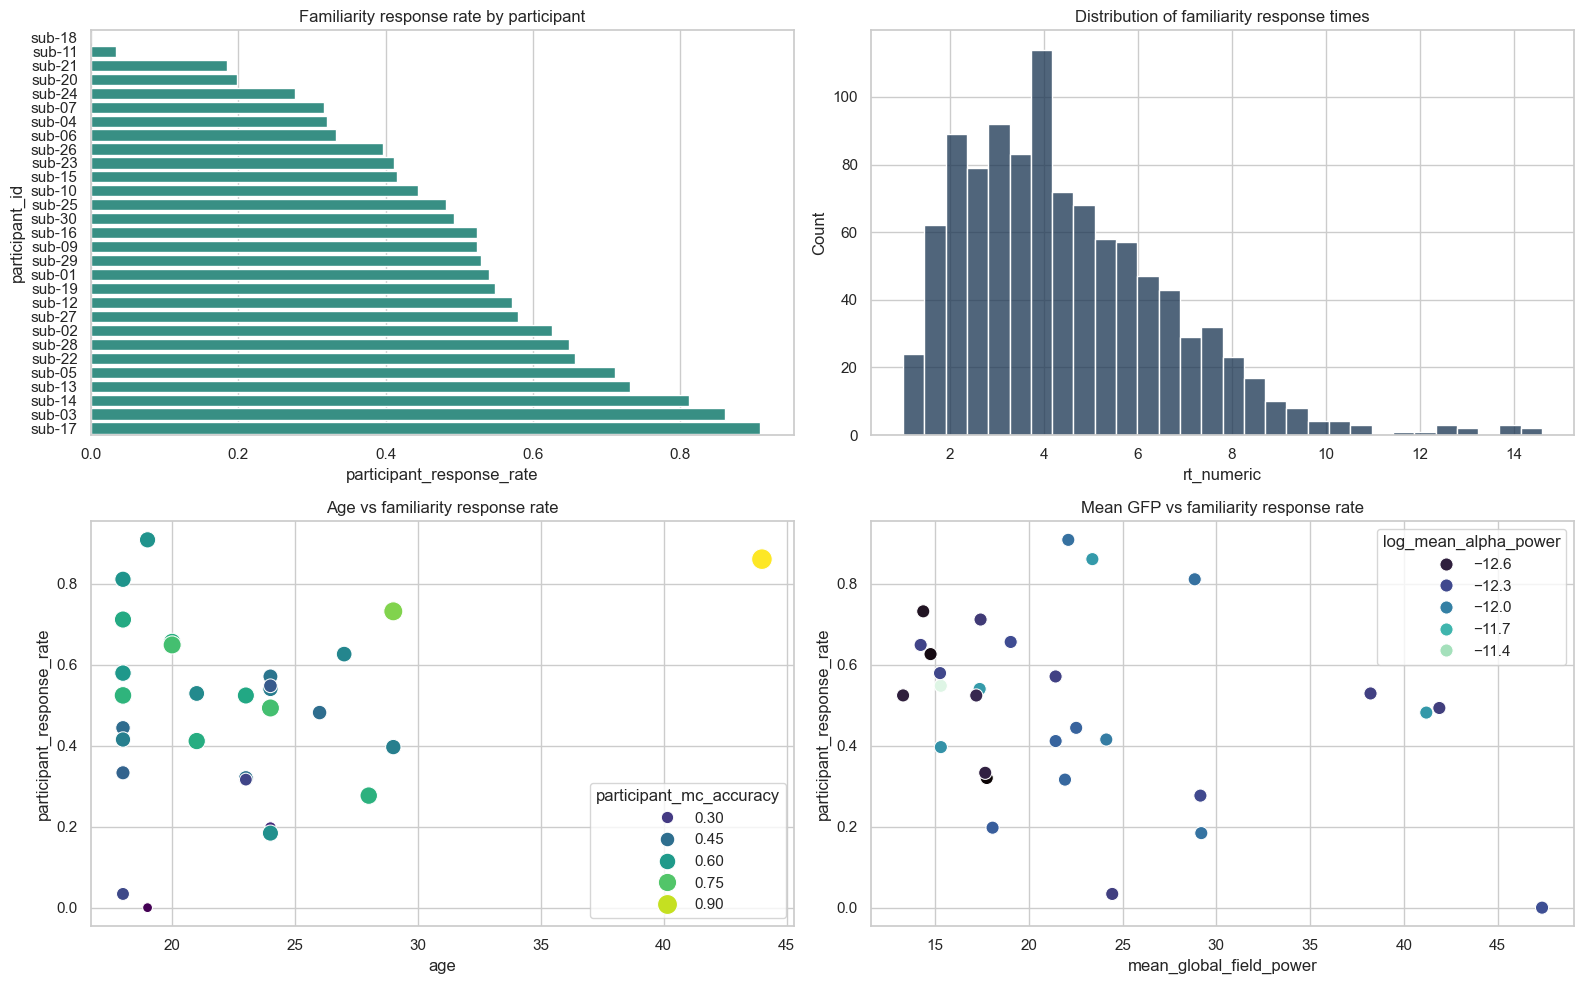

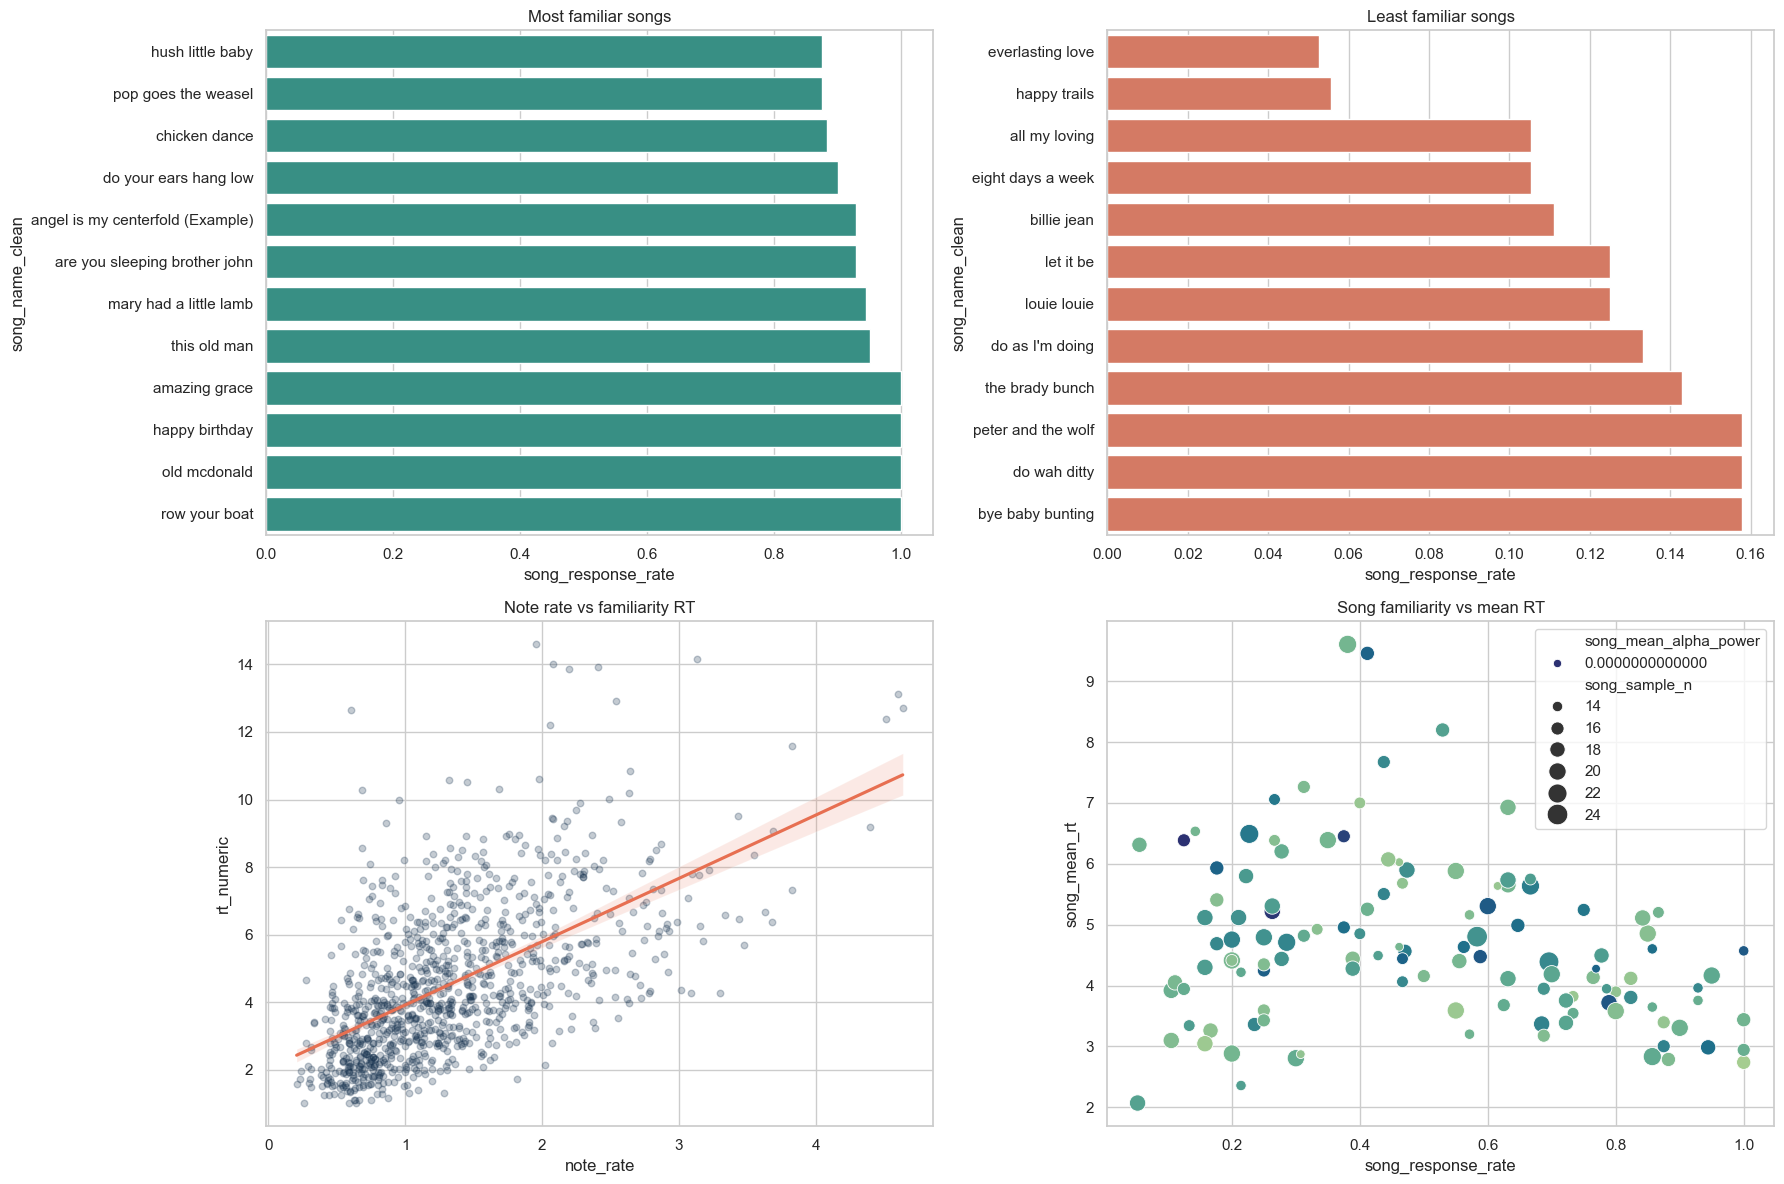

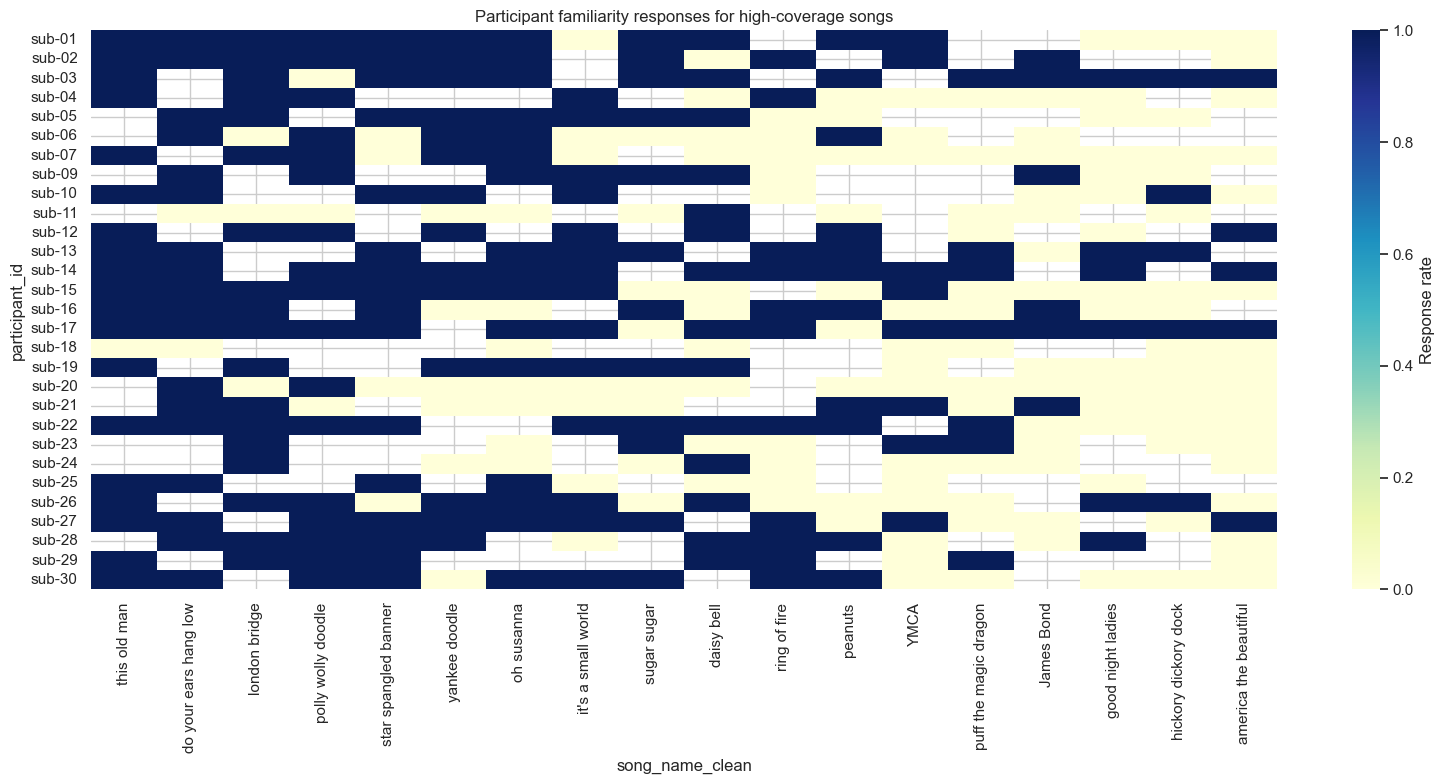

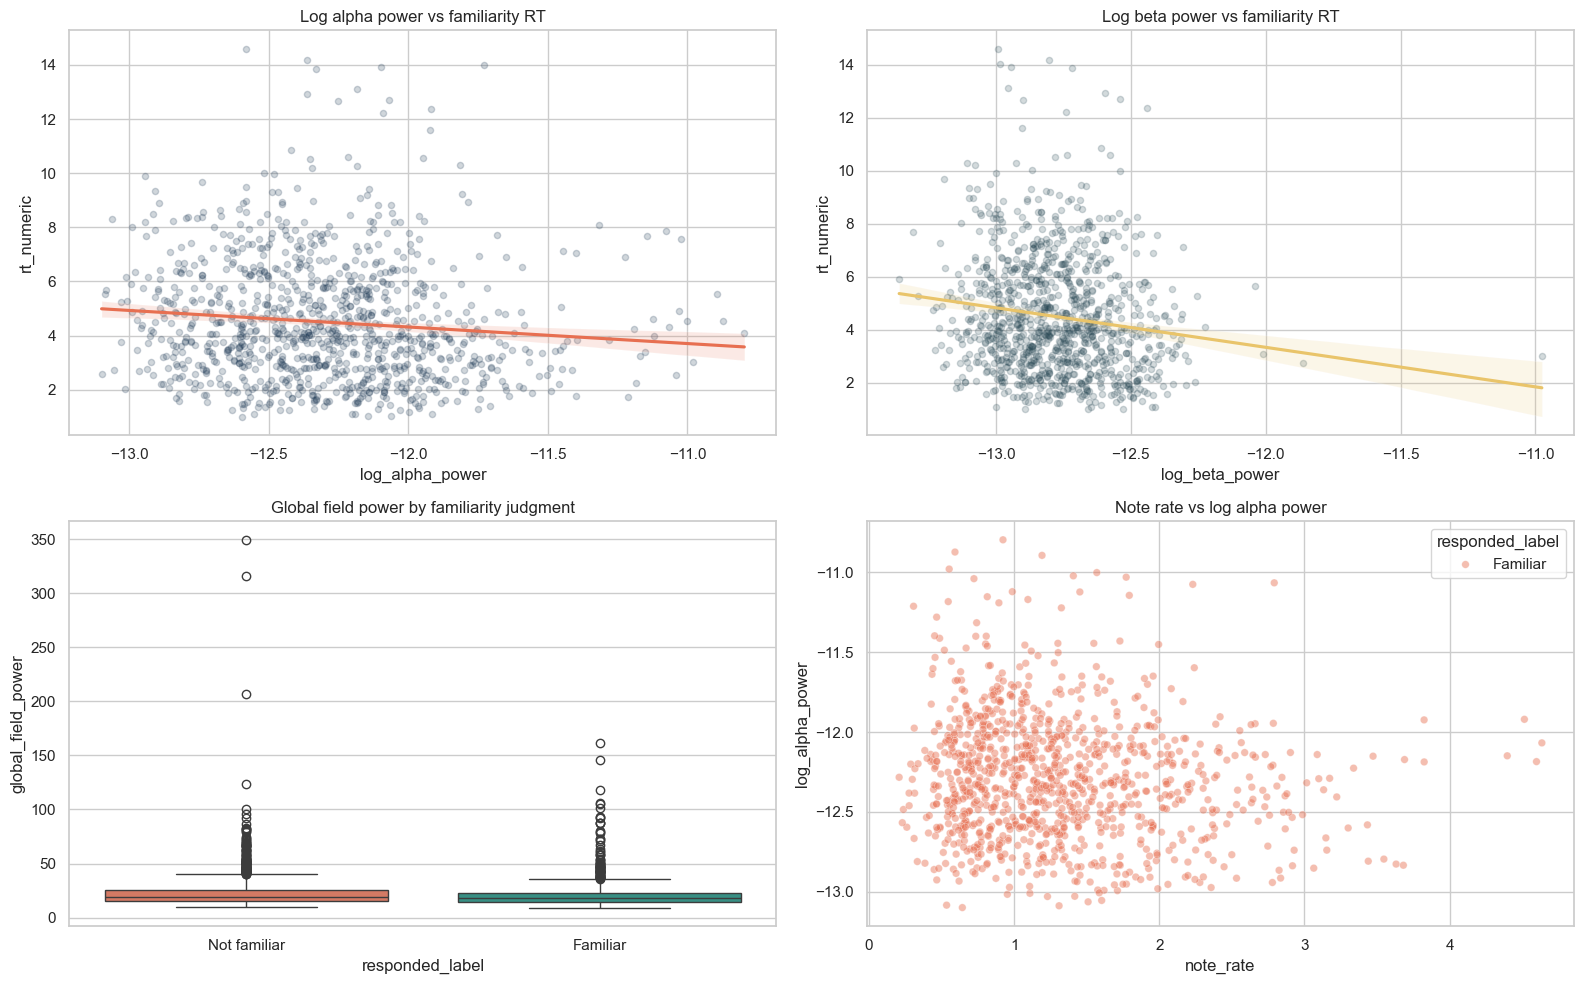

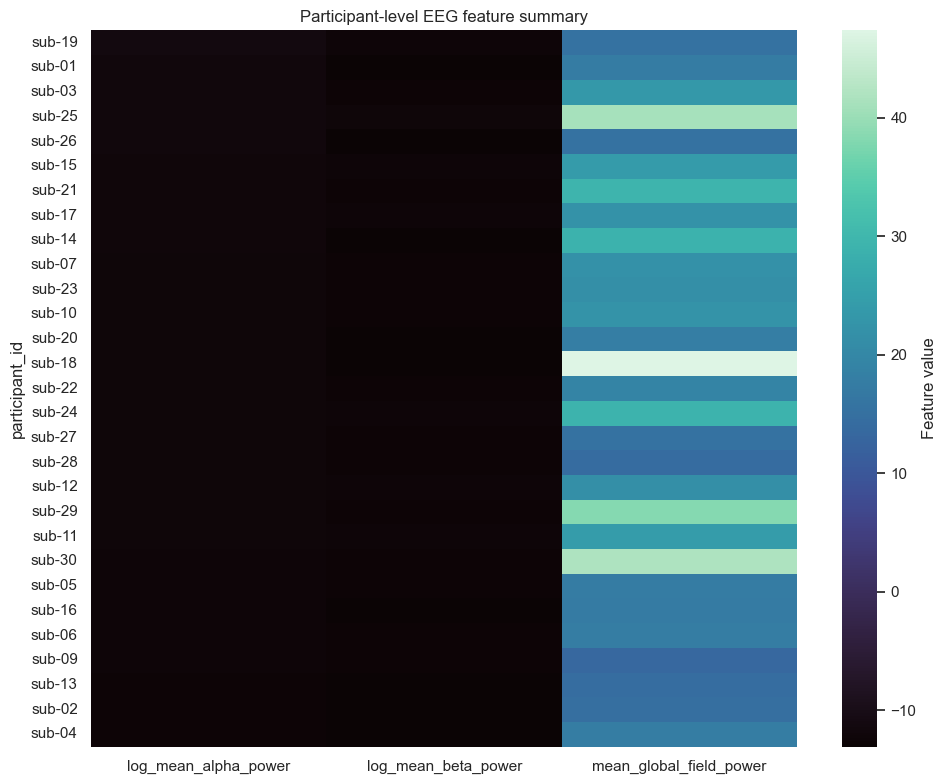

['channel_familiarity_prediction_summary.png', 'csp_lda_familiarity_summary.png', 'csp_lda_loso_diagnostics.png', 'csp_lda_premodeling_overview.png', 'csp_lda_premodeling_topographies.png', 'csp_lda_tuning_diagnostics.png', 'eeg_feature_relationships.png', 'participant_eeg_band_heatmap.png', 'participant_familiarity_overview.png', 'participant_song_familiarity_heatmap.png', 'song_familiarity_patterns.png']


In [2]:
# Build filtered analysis subsets so the diagnostic plots reflect comparable rows.
responded_trials = trial_df[trial_df["valid_familiarity_rt"]].copy()
frequent_songs = song_summary[song_summary["song_sample_n"] >= 10].copy()
eeg_ready_trials = trial_df.dropna(
    subset=["log_alpha_power", "log_beta_power", "global_field_power"]
).copy()
responded_eeg_trials = eeg_ready_trials[eeg_ready_trials["valid_familiarity_rt"]].copy()

# Participant-level diagnostics: response rates, RT distribution, and broad
# demographic / EEG correlates after the merge is complete.
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ordered_participants = participant_summary.sort_values("participant_response_rate")
sns.barplot(
    data=ordered_participants,
    y="participant_id",
    x="participant_response_rate",
    color=PALETTE[1],
    ax=axes[0, 0],
)
sns.histplot(
    responded_trials,
    x="rt_numeric",
    bins=30,
    color=PALETTE[0],
    edgecolor="white",
    ax=axes[0, 1],
)
sns.scatterplot(
    data=participant_summary,
    x="age",
    y="participant_response_rate",
    size="participant_mc_accuracy",
    sizes=(50, 220),
    hue="participant_mc_accuracy",
    palette="viridis",
    ax=axes[1, 0],
)
sns.scatterplot(
    data=participant_summary,
    x="mean_global_field_power",
    y="participant_response_rate",
    hue="log_mean_alpha_power",
    palette="mako",
    s=90,
    ax=axes[1, 1],
)
axes[0, 0].set_title("Familiarity response rate by participant")
axes[0, 1].set_title("Distribution of familiarity response times")
axes[1, 0].set_title("Age vs familiarity response rate")
axes[1, 1].set_title("Mean GFP vs familiarity response rate")
plt.tight_layout()
fig.savefig(PLOT_DIR / "participant_familiarity_overview.png", dpi=200, bbox_inches="tight")
plt.show()

# Song-level diagnostics: identify consistently easy and hard melodies, then
# compare note density and mean RT at the song level.
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
top_songs = (
    frequent_songs.sort_values("song_response_rate", ascending=False)
    .head(12)
    .sort_values("song_response_rate")
)
bottom_songs = (
    frequent_songs.sort_values("song_response_rate", ascending=True)
    .head(12)
    .sort_values("song_response_rate")
)
sns.barplot(
    data=top_songs,
    y="song_name_clean",
    x="song_response_rate",
    color=PALETTE[1],
    ax=axes[0, 0],
)
sns.barplot(
    data=bottom_songs,
    y="song_name_clean",
    x="song_response_rate",
    color=PALETTE[3],
    ax=axes[0, 1],
)
sns.regplot(
    data=responded_trials,
    x="note_rate",
    y="rt_numeric",
    scatter_kws={"alpha": 0.25, "s": 22, "color": PALETTE[0]},
    line_kws={"color": PALETTE[3]},
    ax=axes[1, 0],
)
sns.scatterplot(
    data=frequent_songs.dropna(subset=["song_mean_rt"]),
    x="song_response_rate",
    y="song_mean_rt",
    size="song_sample_n",
    sizes=(40, 220),
    hue="song_mean_alpha_power",
    palette="crest",
    ax=axes[1, 1],
)
axes[0, 0].set_title("Most familiar songs")
axes[0, 1].set_title("Least familiar songs")
axes[1, 0].set_title("Note rate vs familiarity RT")
axes[1, 1].set_title("Song familiarity vs mean RT")
plt.tight_layout()
fig.savefig(PLOT_DIR / "song_familiarity_patterns.png", dpi=200, bbox_inches="tight")
plt.show()

# The participant-by-song heatmap helps verify that the merged trial table still
# preserves the strong between-song and between-participant structure in the data.
heatmap_songs = (
    frequent_songs.sort_values(["song_sample_n", "song_response_rate"], ascending=[False, False])
    .head(18)["songFileName"]
)
heatmap_df = trial_df[trial_df["songFileName"].isin(heatmap_songs)].pivot_table(
    index="participant_id",
    columns="song_name_clean",
    values="responded",
    aggfunc="mean",
)
heatmap_df = heatmap_df.loc[:, heatmap_df.mean().sort_values(ascending=False).index]
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_df, cmap="YlGnBu", vmin=0, vmax=1, cbar_kws={"label": "Response rate"})
plt.title("Participant familiarity responses for high-coverage songs")
plt.tight_layout()
plt.savefig(PLOT_DIR / "participant_song_familiarity_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

# EEG diagnostics: inspect whether the trial-level neural summaries appear to vary
# sensibly with RT, familiarity judgments, and note density.
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.regplot(
    data=responded_eeg_trials,
    x="log_alpha_power",
    y="rt_numeric",
    scatter_kws={"alpha": 0.2, "s": 20, "color": PALETTE[0]},
    line_kws={"color": PALETTE[3]},
    ax=axes[0, 0],
)
sns.regplot(
    data=responded_eeg_trials,
    x="log_beta_power",
    y="rt_numeric",
    scatter_kws={"alpha": 0.2, "s": 20, "color": PALETTE[5]},
    line_kws={"color": PALETTE[2]},
    ax=axes[0, 1],
)
sns.boxplot(
    data=eeg_ready_trials,
    x="responded_label",
    y="global_field_power",
    palette=[PALETTE[3], PALETTE[1]],
    ax=axes[1, 0],
)
sns.scatterplot(
    data=responded_eeg_trials,
    x="note_rate",
    y="log_alpha_power",
    hue="responded_label",
    palette=[PALETTE[3], PALETTE[1]],
    alpha=0.45,
    s=30,
    ax=axes[1, 1],
)
axes[0, 0].set_title("Log alpha power vs familiarity RT")
axes[0, 1].set_title("Log beta power vs familiarity RT")
axes[1, 0].set_title("Global field power by familiarity judgment")
axes[1, 1].set_title("Note rate vs log alpha power")
plt.tight_layout()
fig.savefig(PLOT_DIR / "eeg_feature_relationships.png", dpi=200, bbox_inches="tight")
plt.show()

# Finish with a compact participant-level heatmap of the EEG summaries that were
# generated earlier in the extraction pipeline.
participant_band_heatmap = participant_summary.set_index("participant_id")[
    ["log_mean_alpha_power", "log_mean_beta_power", "mean_global_field_power"]
].sort_values("log_mean_alpha_power", ascending=False)
plt.figure(figsize=(10, 8))
sns.heatmap(participant_band_heatmap, cmap="mako", cbar_kws={"label": "Feature value"})
plt.title("Participant-level EEG feature summary")
plt.tight_layout()
plt.savefig(PLOT_DIR / "participant_eeg_band_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

print(sorted(path.name for path in PLOT_DIR.glob("*.png")))


## 3. Schema Check

The final cell prints the complete trial-level schema after all merges and feature engineering steps have finished. This is useful for two reasons:

1. It confirms that the notebook exported the exact feature names expected by later notebooks.
2. It shows which columns are raw behavioral fields, which were derived from event logs, which came from participant metadata, and which were added from EEG summarization or grouped aggregates.

In practice, this schema dump is the quickest way to verify that a downstream modeling notebook is selecting columns that really exist in `analysis_ready_familiarity_trials.csv`.


In [3]:
trial_df.columns

Index(['trialNum', 'songNumber', 'songFileName', 'songDur', 'fixTime',
       'responded', 'rt', 'postMusicTime', 'reply', 'promptRT', 'choicesMC',
       'respMC', 'rtMC', 'outcomeMC', 'preFeedbackTime', 'participant_id',
       'trial_index', 'note_count', 'trial_window_sec', 'note_rate',
       'rt_numeric', 'promptRT_numeric', 'rtMC_numeric', 'datetime', 'age',
       'sex', 'handedness', 'cch', 'session_date', 'session_month',
       'session_weekday', 'global_field_power', 'delta_power', 'theta_power',
       'alpha_power', 'beta_power', 'reply_present', 'valid_familiarity_rt',
       'responded_label', 'trial_progress', 'age_zscore', 'song_name_clean',
       'log_delta_power', 'log_theta_power', 'log_alpha_power',
       'log_beta_power', 'participant_trial_count',
       'participant_response_rate', 'participant_mc_accuracy',
       'participant_median_rt', 'mean_global_field_power', 'mean_alpha_power',
       'mean_beta_power', 'log_mean_alpha_power', 'log_mean_beta_power',
 